# 06. Автоматическое реферирование (Ollama + Qwen2.5)

## 1. Импорты и настройка путей

In [1]:
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR  = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "figures"
for p in (OUTPUT_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "qwen2.5:7b"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis


## 2. Проверка соединения с Ollama

In [2]:
def check_ollama() -> bool:
    try:
        resp = requests.get("http://localhost:11434", timeout=5)
        return resp.status_code == 200
    except Exception:
        return False

if check_ollama():
    print("Ollama запущена и доступна.")
else:
    print("Ollama недоступна")

Ollama запущена и доступна.


## 3. Загрузка данных

In [3]:
df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)

# Колонка с очищенным текстом называется clean_text
df = df[df["clean_text"].notna() & (df["clean_text"].str.len() > 100)].reset_index(drop=True)

# abstract, title, author не сохранялись в 01_data_preprocessing.ipynb 
# Они извлекаются заново из исходных .tex файлов через text_preprocessing.py
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from text_preprocessing import extract_metadata, read_text_file

meta_rows = []
for _, row in df.iterrows():
    tex_path = Path(row["path"])
    try:
        raw = read_text_file(tex_path)
        meta = extract_metadata(raw)
    except Exception:
        meta = {"title": "", "author": "", "abstract": ""}
    meta_rows.append(meta)

meta_df = pd.DataFrame(meta_rows)
df = pd.concat([df.reset_index(drop=True), meta_df], axis=1)

# Подгрузка доминирующих тем из BigARTM (если файл есть)
topics_path = OUTPUT_DIR / "bigartm_documents_topics.csv"
if topics_path.exists():
    topics_df = pd.read_csv(topics_path)[["filename", "dominant_topic"]]
    df = df.merge(topics_df, on="filename", how="left")
    print("Темы BigARTM загружены.")
else:
    df["dominant_topic"] = "—"
    print("Файл с темами не найден")

# Документы с авторским abstract - для оценки ROUGE
df_with_abstract = df[
    df["abstract"].notna() & (df["abstract"].str.len() > 20)
].copy()

print(f"Всего документов: {len(df)}")
print(f"Документов с авторским abstract: {len(df_with_abstract)}")
print(f"\nПример очищенного текста (300 символов):")
print(df["clean_text"].iloc[0][:300])

Темы BigARTM загружены.
Всего документов: 6385
Документов с авторским abstract: 1

Пример очищенного текста (300 символов):
предположение обратимость линейный разностный оператор постоянный коэффициент пусть комплексный банаховы пространство банахово пространство линейный ограниченный оператор гомоморфизм действовать банахова алгебра эндоморфизм банахова пространство символ использоваться обозначение тождественный операт


## 4. Функция генерации аннотации

In [4]:
# Qwen2.5:7b имеет контекстное окно ~8k токенов.
# 4000 символов = ~2000–2500 токенов - безопасный лимит для русского текста.
MAX_TEXT_CHARS = 4000

PROMPT_TEMPLATE = """Ты — научный редактор, специализирующийся на математических публикациях.
Напиши краткую аннотацию (3–5 предложений) следующей математической статьи на русском языке.
Аннотация должна отражать: основную тему и задачу, используемые методы, главный результат.
Пиши только аннотацию, без пояснений и вводных фраз.

Текст статьи:
{text}

Аннотация:"""


def generate_summary(
    text: str,
    model: str = OLLAMA_MODEL,
    max_chars: int = MAX_TEXT_CHARS,
    timeout: int = 120,
) -> str:
    """Отправляет текст в Ollama и возвращает сгенерированную аннотацию."""
    prompt = PROMPT_TEMPLATE.format(text=text[:max_chars])
    payload = {
        "model":  model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.3, # низкая температура = стабильный фактический текст
            "top_p": 0.9,
            "num_predict": 300, # максимум токенов в ответе
        },
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        resp.raise_for_status()
        return resp.json().get("response", "").strip()
    except requests.exceptions.Timeout:
        return "[ОШИБКА: таймаут]"
    except Exception as e:
        return f"[ОШИБКА: {e}]"


# Тест на одном документе
print("Тест генерации (первый документ)...")
test_summary = generate_summary(df["clean_text"].iloc[0])
print(f"\nФайл: {df['filename'].iloc[0]}")
print(f"Аннотация: {test_summary}")

Тест генерации (первый документ)...

Файл: 00-5-2001.tex
Аннотация: Статья исследует обратимость линейного разностного оператора с постоянными коэффициентами в комплексном банаховом пространстве. Используются методы спектральной теории и теории дифференциальных уравнений. Основной результат — достаточные условия обратимости разностного оператора, связанные с свойствами его символа и резольвентного множества.


## 5. Генерация аннотаций для всего корпуса

In [5]:
# Генерирация для документов с авторским abstract - они нужны для оценки ROUGE.
# (Чтобы реферировать весь корпус - заменить df_with_abstract на df)
TARGET_DF = df_with_abstract.copy()

summaries = []
start_time = time.time()

for _, row in tqdm(TARGET_DF.iterrows(), total=len(TARGET_DF), desc="Генерация аннотаций"):
    summaries.append(generate_summary(row["clean_text"]))

elapsed = time.time() - start_time
print(f"\nГотово: {len(summaries)} документов за {elapsed:.0f} сек. "
      f"({elapsed / len(summaries):.1f} сек/документ)")

TARGET_DF = TARGET_DF.copy()
TARGET_DF["generated_summary"] = summaries

# Сразу сохранение (если следующие ячейки упадут)
save_cols = [c for c in ["filename", "title", "author", "abstract",
                          "dominant_topic", "generated_summary"] if c in TARGET_DF.columns]
TARGET_DF[save_cols].to_csv(OUTPUT_DIR / "summaries_raw.csv", index=False, encoding="utf-8")
print("Промежуточный результат сохранён:", OUTPUT_DIR / "summaries_raw.csv")

Генерация аннотаций: 100%|██████████| 1/1 [01:04<00:00, 64.62s/it]


Готово: 1 документов за 65 сек. (64.6 сек/документ)
Промежуточный результат сохранён: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\summaries_raw.csv


In [6]:
# Просмотр нескольких примеров
for _, row in TARGET_DF.head(3).iterrows():
    print(f"Файл:          {row['filename']}")
    if pd.notna(row.get('title')):
        print(f"Заголовок: {str(row['title'])[:80]}")
    print(f"Авторский abs: {str(row['abstract'])[:250]}")
    print(f"Сгенерировано: {str(row['generated_summary'])[:250]}")

Файл:          polieces.tex
Заголовок: 
Авторский abs: Журнал «Вестник Самарского государственного технического университета. Серия: Физико" математические науки» (параллельное название на английском языке "--- Journal of Samara State Technical University, Ser. Physical and Mathematical Sciences) являетс
Сгенерировано: Статья посвящена редакционной политике журнала "Вестник Самарского государственного технического университета. Серия Физико-математические науки", который специализируется на публикациях в области дифференциальных уравнений, математической физики, ме


## 6. Оценка качества - ROUGE

In [7]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False, # Для русского стемминг отключен
)

rouge_records = []
for _, row in TARGET_DF.iterrows():
    ref = str(row["abstract"]).strip()
    hyp = str(row["generated_summary"]).strip()
    base = {"filename": row["filename"]}

    if not ref or not hyp or hyp.startswith("[ОШИБКА"):
        rouge_records.append({**base,
            "rouge1_f": None, "rouge2_f": None, "rougeL_f": None,
            "rouge1_p": None, "rouge2_p": None, "rougeL_p": None,
            "rouge1_r": None, "rouge2_r": None, "rougeL_r": None})
        continue

    s = scorer.score(ref, hyp)
    rouge_records.append({**base,
        "rouge1_f": s["rouge1"].fmeasure,  "rouge2_f": s["rouge2"].fmeasure,  "rougeL_f": s["rougeL"].fmeasure,
        "rouge1_p": s["rouge1"].precision,  "rouge2_p": s["rouge2"].precision,  "rougeL_p": s["rougeL"].precision,
        "rouge1_r": s["rouge1"].recall,    "rouge2_r": s["rouge2"].recall,    "rougeL_r": s["rougeL"].recall})

rouge_df = pd.DataFrame(rouge_records)

print("ROUGE-метрики (среднее по корпусу):")
print(f"  ROUGE-1 F1: {rouge_df['rouge1_f'].mean():.4f}")
print(f"  ROUGE-2 F1: {rouge_df['rouge2_f'].mean():.4f}")
print(f"  ROUGE-L F1: {rouge_df['rougeL_f'].mean():.4f}")

ROUGE-метрики (среднее по корпусу):
  ROUGE-1 F1: 0.0000
  ROUGE-2 F1: 0.0000
  ROUGE-L F1: 0.0000


## 7. Оценка качества - BERTScore

In [8]:
from bert_score import score as bert_score

valid_mask = (
    TARGET_DF["abstract"].notna() &
    TARGET_DF["generated_summary"].notna() &
    ~TARGET_DF["generated_summary"].str.startswith("[ОШИБКА")
)
valid_df = TARGET_DF[valid_mask].copy()

print(f"Вычисление BERTScore для {len(valid_df)} документов...")

# (Первый запуск загружает модель)
P, R, F1 = bert_score(
    valid_df["generated_summary"].tolist(),
    valid_df["abstract"].tolist(),
    lang="ru",
    model_type="intfloat/multilingual-e5-small",
    num_layers=12,
    verbose=True,
)

valid_df = valid_df.copy()
valid_df["bertscore_p"]  = P.numpy()
valid_df["bertscore_r"]  = R.numpy()
valid_df["bertscore_f1"] = F1.numpy()

print(f"\nBERTScore (среднее по корпусу):")
print(f"  Precision: {P.mean():.4f}")
print(f"  Recall:    {R.mean():.4f}")
print(f"  F1:        {F1.mean():.4f}")

Вычисление BERTScore для 1 документов...
calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:00<00:00,  2.09it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 73.17it/s]

done in 0.50 seconds, 2.00 sentences/sec

BERTScore (среднее по корпусу):
  Precision: 0.8744
  Recall:    0.8453
  F1:        0.8596


## 8. Сводная таблица метрик

In [9]:
rouge_valid = rouge_df[rouge_df["filename"].isin(valid_df["filename"])]

metrics_df = valid_df[
    ["filename", "dominant_topic", "bertscore_p", "bertscore_r", "bertscore_f1"]
].merge(rouge_valid, on="filename", how="left")

metrics_df.to_csv(OUTPUT_DIR / "summarization_metrics.csv", index=False, encoding="utf-8")
print("Метрики сохранены:", OUTPUT_DIR / "summarization_metrics.csv")

summary_stats = pd.DataFrame([{
    "model":        OLLAMA_MODEL,
    "documents":    len(metrics_df),
    "rouge1_f1":    metrics_df["rouge1_f"].mean(),
    "rouge2_f1":    metrics_df["rouge2_f"].mean(),
    "rougeL_f1":    metrics_df["rougeL_f"].mean(),
    "bertscore_f1": metrics_df["bertscore_f1"].mean(),
}])
summary_stats.to_csv(OUTPUT_DIR / "summarization_summary.csv", index=False)

print("\nИтоговые метрики:")
print(summary_stats.to_string(index=False))

Метрики сохранены: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\summarization_metrics.csv

Итоговые метрики:
     model  documents  rouge1_f1  rouge2_f1  rougeL_f1  bertscore_f1
qwen2.5:7b          1        0.0        0.0        0.0      0.859601


## 9. Визуализация результатов

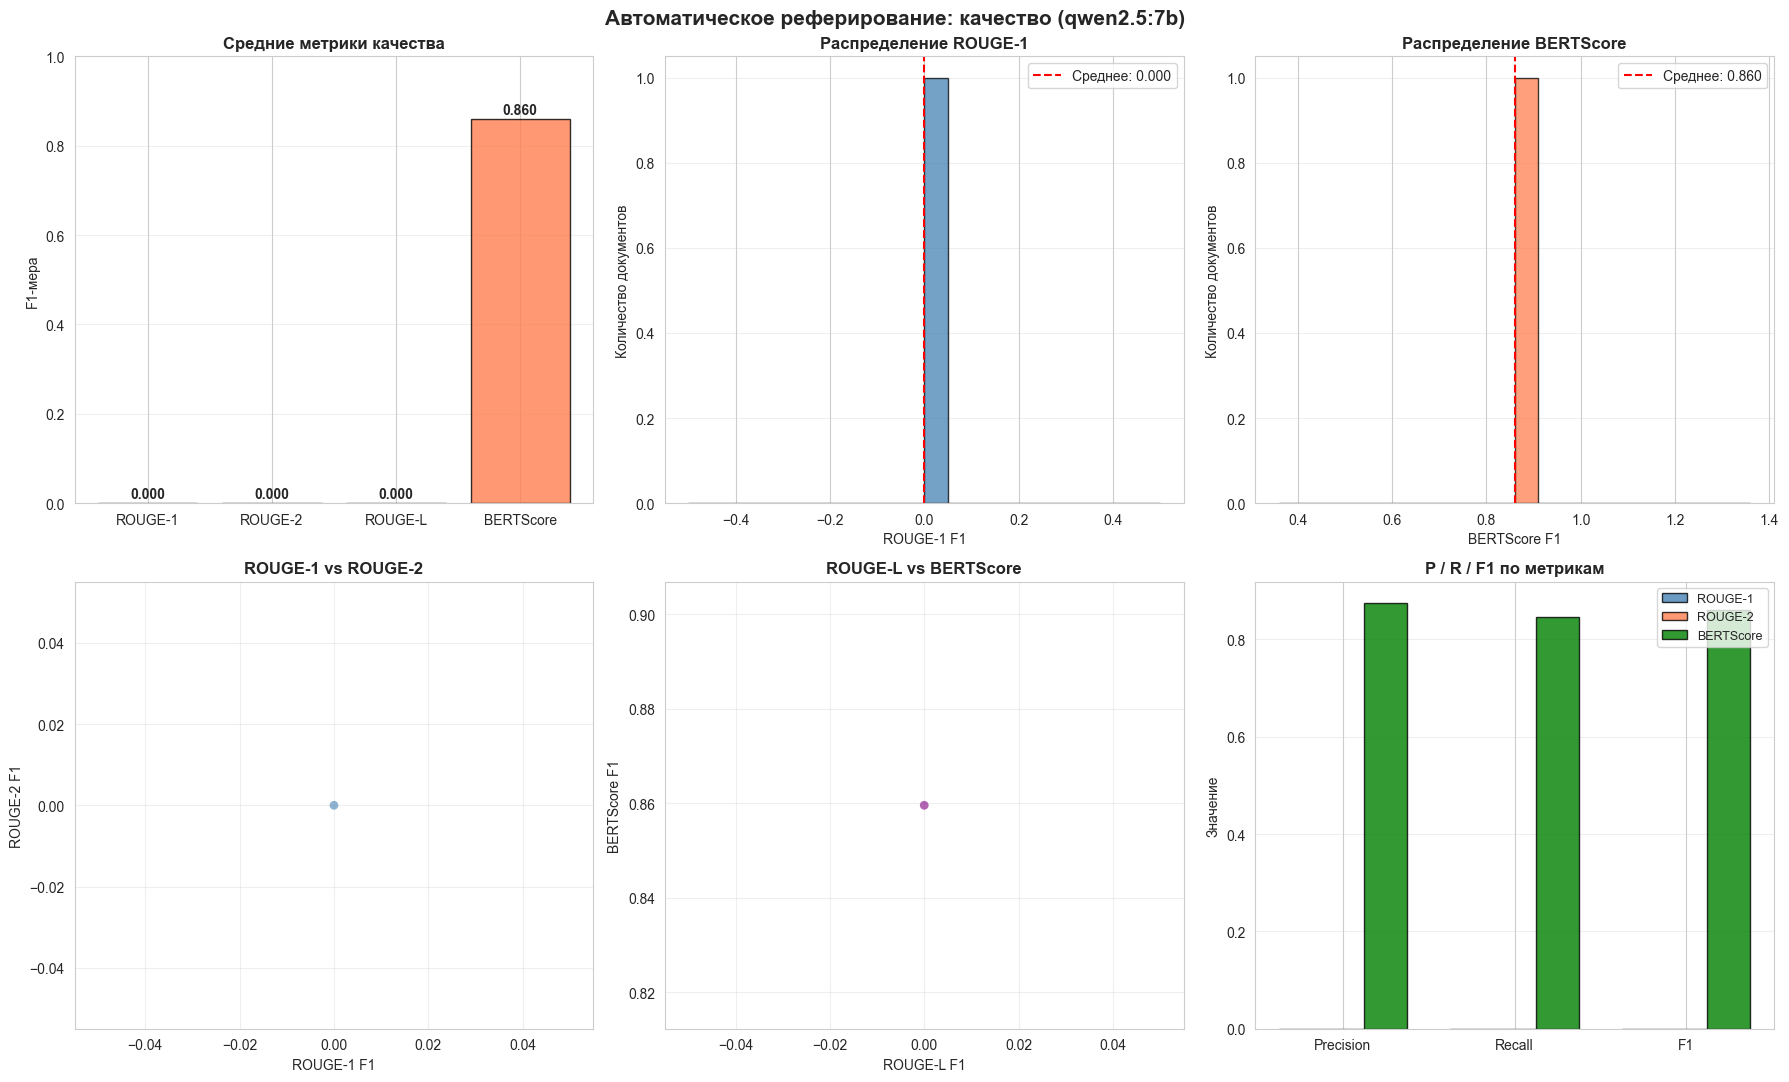

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\summarization_metrics.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Средние ROUGE и BERTScore
ax = axes[0, 0]
metric_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore"]
metric_vals = [
    metrics_df["rouge1_f"].mean(),
    metrics_df["rouge2_f"].mean(),
    metrics_df["rougeL_f"].mean(),
    metrics_df["bertscore_f1"].mean(),
]
bar_colors = ["steelblue", "steelblue", "steelblue", "coral"]
bars = ax.bar(metric_names, metric_vals, color=bar_colors, alpha=0.8, edgecolor="black")
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005, f"{val:.3f}",
            ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylim(0, min(1.0, max(metric_vals) * 1.25))
ax.set_ylabel("F1-мера")
ax.set_title("Средние метрики качества", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Распределение ROUGE-1
ax = axes[0, 1]
data_r1 = metrics_df["rouge1_f"].dropna()
ax.hist(data_r1, bins=20, color="steelblue", alpha=0.75, edgecolor="black")
ax.axvline(data_r1.mean(), color="red", linestyle="--",
           label=f"Среднее: {data_r1.mean():.3f}")
ax.set_xlabel("ROUGE-1 F1")
ax.set_ylabel("Количество документов")
ax.set_title("Распределение ROUGE-1", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Распределение BERTScore
ax = axes[0, 2]
data_bs = metrics_df["bertscore_f1"].dropna()
ax.hist(data_bs, bins=20, color="coral", alpha=0.75, edgecolor="black")
ax.axvline(data_bs.mean(), color="red", linestyle="--",
           label=f"Среднее: {data_bs.mean():.3f}")
ax.set_xlabel("BERTScore F1")
ax.set_ylabel("Количество документов")
ax.set_title("Распределение BERTScore", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ROUGE-1 vs ROUGE-2
ax = axes[1, 0]
ax.scatter(metrics_df["rouge1_f"], metrics_df["rouge2_f"],
           alpha=0.6, color="steelblue", s=40, edgecolors="none")
ax.set_xlabel("ROUGE-1 F1")
ax.set_ylabel("ROUGE-2 F1")
ax.set_title("ROUGE-1 vs ROUGE-2", fontweight="bold")
ax.grid(True, alpha=0.3)

# ROUGE-L vs BERTScore
ax = axes[1, 1]
ax.scatter(metrics_df["rougeL_f"], metrics_df["bertscore_f1"],
           alpha=0.6, color="purple", s=40, edgecolors="none")
ax.set_xlabel("ROUGE-L F1")
ax.set_ylabel("BERTScore F1")
ax.set_title("ROUGE-L vs BERTScore", fontweight="bold")
ax.grid(True, alpha=0.3)

# Precision, Recall, F1 по метрикам
ax = axes[1, 2]
groups = {
    "ROUGE-1":   [metrics_df["rouge1_p"].mean(), metrics_df["rouge1_r"].mean(), metrics_df["rouge1_f"].mean()],
    "ROUGE-2":   [metrics_df["rouge2_p"].mean(), metrics_df["rouge2_r"].mean(), metrics_df["rouge2_f"].mean()],
    "BERTScore": [metrics_df["bertscore_p"].mean(), metrics_df["bertscore_r"].mean(), metrics_df["bertscore_f1"].mean()],
}
x = np.arange(3)
width = 0.25
for i, (name, vals) in enumerate(groups.items()):
    ax.bar(x + i * width, vals, width, label=name,
           color=["steelblue", "coral", "green"][i], alpha=0.8, edgecolor="black")
ax.set_xticks(x + width)
ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylabel("Значение")
ax.set_title("P / R / F1 по метрикам", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Автоматическое реферирование: качество ({OLLAMA_MODEL})",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "summarization_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "summarization_metrics.png")

## 10. Лучшие и худшие аннотации по ROUGE-1

In [11]:
full_df = valid_df.merge(rouge_valid, on="filename", how="left")

def print_examples(subset: pd.DataFrame, label: str) -> None:
    print(label)
    for _, row in subset.iterrows():
        print(f"Файл:          {row['filename']}")
        print(f"ROUGE-1 F1:    {row['rouge1_f']:.4f}  |  BERTScore: {row['bertscore_f1']:.4f}")
        print(f"Авторский:     {str(row['abstract'])[:250]}")
        print(f"Сгенерирован.: {str(row['generated_summary'])[:250]}")

print_examples(full_df.nlargest(3, "rouge1_f"),  "ТОП-3: наилучшие аннотации (ROUGE-1 F1)")
print_examples(full_df.nsmallest(3, "rouge1_f"), "ТОП-3: наихудшие аннотации (ROUGE-1 F1)")

ТОП-3: наилучшие аннотации (ROUGE-1 F1)
Файл:          polieces.tex
ROUGE-1 F1:    0.0000  |  BERTScore: 0.8596
Авторский:     Журнал «Вестник Самарского государственного технического университета. Серия: Физико" математические науки» (параллельное название на английском языке "--- Journal of Samara State Technical University, Ser. Physical and Mathematical Sciences) являетс
Сгенерирован.: Статья посвящена редакционной политике журнала "Вестник Самарского государственного технического университета. Серия Физико-математические науки", который специализируется на публикациях в области дифференциальных уравнений, математической физики, ме
ТОП-3: наихудшие аннотации (ROUGE-1 F1)
Файл:          polieces.tex
ROUGE-1 F1:    0.0000  |  BERTScore: 0.8596
Авторский:     Журнал «Вестник Самарского государственного технического университета. Серия: Физико" математические науки» (параллельное название на английском языке "--- Journal of Samara State Technical University, Ser. Physical and Mathemati

## 11. Итоговое сохранение

In [12]:
final_cols = [
    "filename", "title", "author", "abstract",
    "dominant_topic", "generated_summary",
    "rouge1_f", "rouge2_f", "rougeL_f",
    "bertscore_f1",
]
final_cols = [c for c in final_cols if c in full_df.columns]
full_df[final_cols].to_csv(OUTPUT_DIR / "summaries.csv", index=False, encoding="utf-8")

print("Итоговый файл сохранён:", OUTPUT_DIR / "summaries.csv")
print(f"Строк: {len(full_df)}, колонок: {len(final_cols)}")
print("Колонки:", final_cols)

Итоговый файл сохранён: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\summaries.csv
Строк: 1, колонок: 10
Колонки: ['filename', 'title', 'author', 'abstract', 'dominant_topic', 'generated_summary', 'rouge1_f', 'rouge2_f', 'rougeL_f', 'bertscore_f1']
